# Wiktor Zoga

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(2137)
np.random.seed(2137)

## Step 1 — Load Model
* Load pretrained ResNet18 from torchvision.models
* Set model.eval()

In [34]:
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Obrazki

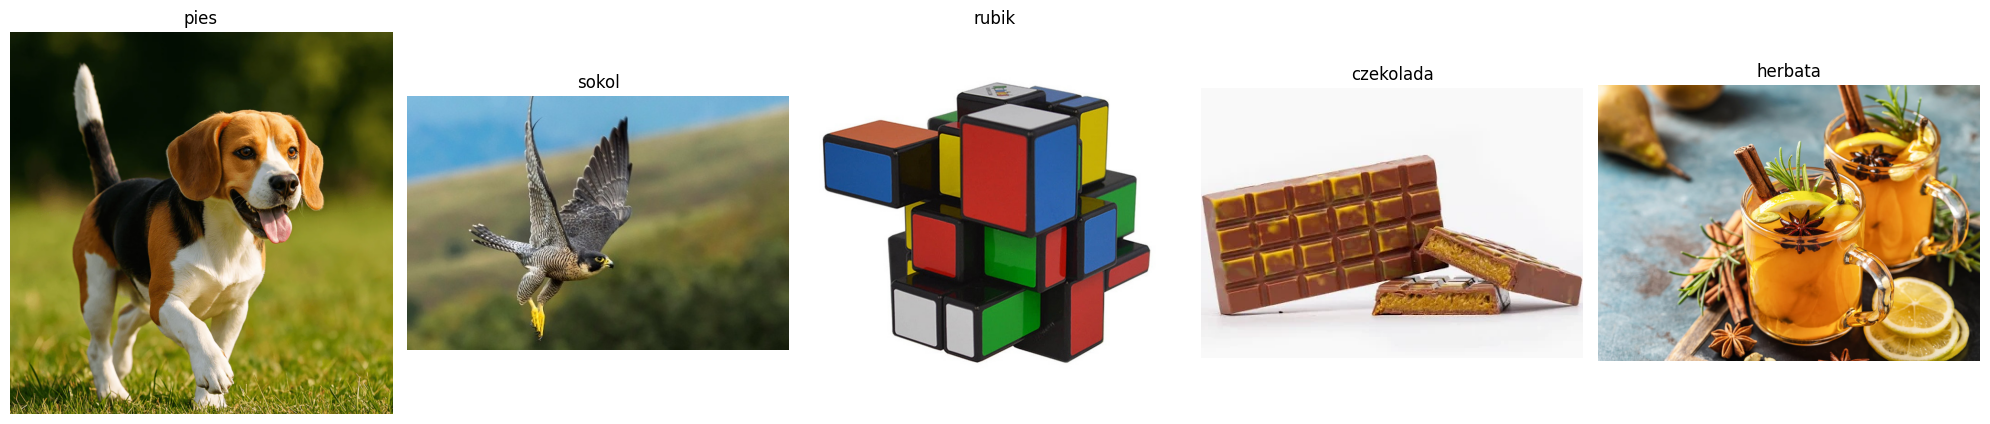

In [35]:
from PIL import Image

img_paths = {'pies': './data/pies.webp', 'sokol': './data/sokol.jpg', 'rubik': './data/rubik.jpg', 'czekolada': './data/czekolada.webp', 'herbata': './data/herbata.jpeg'}

fig, ax = plt.subplots(1, 5, figsize=(20, 5))

for i, (name, path) in enumerate(img_paths.items()):
    img = Image.open(path)
    ax[i].imshow(img)
    ax[i].set_title(name)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

## Step 2 — Image Preprocessing
1. Load 3–5 images
2. Apply correct transforms:
* Resize
* Center crop
* To tensor
* Normalization (ImageNet mean/std)

# Jakie należy wykonać transformacje?

In [36]:
models.ResNet18_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Na podstawie powyższych danych przeprowadzimy tranfomracje. Nie korzystam z transform w torchvision tylko "ręcznie" transformuję. Odbuściłem resampling i cropping bo są to funkcjalności bliblioteki PIL, a w treści zadania nie było specyfikacji jak wykonać tą tranformacje.

Cropping jest oczwyiście trywaialną sprawą. 

Bilnear resampling też jest nietrudną operacją ale troche wymaga do napisania.

Zgrubsza polega na tym, że jak wyliczamy nowe współrzędne pixela to przez skalowanie mogą one wyjśc niecałkowite.
W takim wypadku po rpostu patrzymy na 4 najbliższych sąsiadów danego dla tego miejsca (proste operacje podłogi itp wystarczają jak dobrze kojarzę)
i liczymy wartość tego pixela jako średnia ważona wartości (R, G, B) sąsiadów z wagami jakie zdaje odległość od punktu, w które miał trafić pixel.

In [37]:
imgs = []
imgs_unnormalized = []

for name, path in img_paths.items():
    img = Image.open(path).convert('RGB')

    # resizing to 256 (smaller side)
    w, h = img.size # (w, h) inaczej niż w numpy (h, w)

    scale = 256 / min(w, h)
    new_w, new_h = int(w * scale), int(h * scale)

    img_resized = img.resize((new_w, new_h), resample=Image.Resampling.BILINEAR)

    # cropping 224

    maring_left = (new_w - 224) // 2
    maring_upper = (new_h - 224) // 2

    img_cropped = img_resized.crop(( # left, upper, right, lower 
        maring_left,
        maring_upper,
        maring_left + 224,
        maring_upper + 224
    ))

    # scaling to [0, 1]

    img_np = np.array(img_cropped) / 255.0

    img_tensor = torch.tensor(img_np, dtype=torch.float32).permute(2, 0, 1) # (Height, Width, Color Channels) -> (C, H, W), bo takiej kolejności wymaga ResNet18

    # normalization

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img_normalized = (img_tensor - mean) / std

    imgs.append(img_normalized)
    imgs_unnormalized.append(img_tensor)

imgs_batch = torch.stack(imgs, dim=0) # łączymy w jeden tensor, nasz batch!
imgs_batch_unnormalized = torch.stack(imgs_unnormalized, dim=0)

print(imgs_batch.shape)

torch.Size([5, 3, 224, 224])


## Step 3 — Inference
* Run forward pass
* Extract top-5 predicted classes
* Print class names and probabilities

## Step 4 — Experiment
* Run inference:
* With correct normalization
* Without normalization
* Compare results.

In [40]:
with torch.no_grad(): # żeby torch nic nie liczył, "nie uczył"
    outputs = model(imgs_batch)
    outputs_unnormalized = model(imgs_batch_unnormalized)

print(outputs.shape)

torch.Size([5, 1000])


In [45]:
import torch.nn.functional as F

probabilities = F.softmax(outputs, dim=1)
probabilities_unnormalized = F.softmax(outputs_unnormalized, dim=1)

top_prob, top_catid = torch.topk(probabilities, 5)
top_prob_unnormalized, top_catid_unnormalized = torch.topk(probabilities_unnormalized, 5)

all_categories = np.array(models.ResNet18_Weights.DEFAULT.meta['categories'])

predictions = all_categories[top_catid.numpy()]
predictions_unnormalized = all_categories[top_catid_unnormalized.numpy()]

print("Dla obrazków znormalizowanych")
# Używamy round() dla czytelności (zamieniamy tensor na numpy żeby to zadziałało)
print(f"Prawdopodobieństwa:\n{np.round(top_prob.numpy() * 100, 2)}") 
print(f"Klasy:\n{predictions}")

print('\n\nDla obrazków nieznormalizowanych')
print(f"Prawdopodobieństwa:\n{np.round(top_prob_unnormalized.numpy() * 100, 2)}")
print(f"Klasy:\n{predictions_unnormalized}")

Dla obrazków znormalizowanych
Prawdopodobieństwa:
[[51.21 30.55 16.72  0.52  0.41]
 [79.86  5.26  3.46  3.15  1.08]
 [64.42  4.8   4.47  3.97  3.1 ]
 [56.85  6.78  5.51  2.62  2.43]
 [38.2  10.21  4.52  3.75  2.87]]
Klasy:
[['beagle' 'English foxhound' 'Walker hound' 'bluetick' 'basset']
 ['kite' 'African grey' 'great grey owl' 'prairie chicken' 'terrapin']
 ['file' 'bookcase' 'desk' 'mailbox' 'birdhouse']
 ['studio couch' 'chest' 'hamper' 'harmonica' 'rocking chair']
 ['pot' 'pitcher' 'teapot' 'consomme' 'vase']]


Dla obrazków nieznormalizowanych
Prawdopodobieństwa:
[[41.12 36.33 21.73  0.16  0.1 ]
 [42.43  7.82  4.63  4.01  3.21]
 [64.42 23.42  1.27  1.15  0.98]
 [40.21 13.37 11.7   3.87  2.07]
 [18.41 10.9   7.32  5.87  4.8 ]]
Klasy:
[['English foxhound' 'Walker hound' 'beagle' 'bluetick'
  'Greater Swiss Mountain dog']
 ['kite' 'prairie chicken' 'starfish' 'gar' 'American chameleon']
 ['honeycomb' 'carton' 'pedestal' 'birdhouse' 'digital clock']
 ['studio couch' 'rocking chair' 'd

Wyniki widać, że są lepsze dla normalizacji, udało się nawet zgadnąć rase psa no i ostatnio obrazek herbaty tez bym zaliczył.   
Model nie poradził sobie z szybującym sokołem, bo jako pierwszy output dał latwiec, ale kolejne outputy to są już ptaki!  
Mocno bym się zdziwił gdyby poradził sobie z tą fikuśną kostką rubika.  
Dubajska czekolada też go pokonała.

1. Why do we call model.eval()?  
Dlatego, że chcemy przełączyć model wyłącznie w tryb korzystania z niego (wnioskowania), tzn nie chcemy go już uczyć. Dodatkwo pozwala nam to też przejżeć architekture.  

2. What happens if normalization is skipped?  
Model został wytrenowany z tą konkretną normalizacją. Skoro tak, to jeśli ją pominiemy, nie dopasowujemy się do "klucza" modelu. Tym samym lądujemy z naszymi danymi w zupełnie innym miejscu przestrzeni, niż wytrenowany model zakłada.  

3. What is a logit?  
Logit to zwyczajnie output sieci (gdy chcemy przwidywać ppstwo), który dopiero później będzie zamieniony na prawdopodobieństwo. Sieci neuronowej najłatwiej jest na samym końcu wypluwać po prostu dowolne liczby rzeczywiste, niżeli wartości z $[0, 1]$, większe możliwości dla treninigu i miesza błędy numeryczne

4. Why do we apply softmax for probabilities?  
Softmax to uogólnienie zwykłej funkcji sigmoid, które odpowiednio odwzorowuje wartości z $\mathbb{R}^n$ w przedział $[0, 1]$ (tak, aby sumowały się do 1). Działa to tak, że duże ujemne wartości są spychane bliżej 0, duże dodatnie bliżej 1, a wartości średnie (bliższe zeru) dają uśrednione ułamki. Jest to po prostu uogólnienie funkcji z $\mathbb{R}$ na wielowymiarowe $\mathbb{R}^n$. Nie jest to sigmoid po współrzędnych, jest to odpowiednia średnia ważona, tak aby zachować proporcje pomiędzy wynikami na różnych współrzędnych i razem sumowały się do 1.